# ML - Aprendizaje No Supervisado: Cáncer de Boca

Si bien la mayoría de los ejemplos de *Machine Learning* que se presentan de forma introductoria suelen basarse en aprendizaje supervisado, en muchos casos reales los datos no están etiquetados. En esta práctica vamos a usar técnicas de aprendizaje no supervisado para agrupar imágenes de cáncer de boca por similitud visual. Para facilitar la interpretación, primero convertimos las imágenes a escala de grises, las redimensionamos y luego aplicamos PCA y K-Means.


## 1. Carga del dataset local

Buscamos imágenes dentro de `C:\Users\elmer\Documents\SIS420\archive`. Para simplificar el análisis, las imágenes se convierten a escala de grises y se redimensionan antes de agruparlas. Si más adelante agregas carpetas con etiquetas, el notebook también puede detectarlas.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

In [2]:
data_root = Path(r'C:\Users\elmer\Documents\SIS420\archive')
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
image_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in image_extensions])

if not image_paths:
    raise FileNotFoundError(f'No se encontraron imágenes en {data_root}')

print(f'Imágenes encontradas: {len(image_paths)}')
print('Primeras rutas:')
for path in image_paths[:5]:
    print(' -', path)

Imágenes encontradas: 10002
Primeras rutas:
 - C:\Users\elmer\Documents\SIS420\archive\all unlabeled\oral_normal_0001.jpg
 - C:\Users\elmer\Documents\SIS420\archive\all unlabeled\oral_normal_0002.jpg
 - C:\Users\elmer\Documents\SIS420\archive\all unlabeled\oral_normal_0003.jpg
 - C:\Users\elmer\Documents\SIS420\archive\all unlabeled\oral_normal_0004.jpg
 - C:\Users\elmer\Documents\SIS420\archive\all unlabeled\oral_normal_0005.jpg


In [15]:
def load_images(paths, image_size=(32, 32), max_images=None):
    selected_paths = paths if max_images is None else paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert('L').resize(image_size)
            image_arrays.append(np.asarray(img, dtype=np.float32) / 255.0)
    images = np.stack(image_arrays)
    flat = images.reshape(len(images), -1)
    return images, flat, selected_paths

max_images = None
images, X, used_paths = load_images(image_paths, image_size=(32, 32), max_images=max_images)
print('Shape de imágenes:', images.shape)
print('Shape de X:', X.shape)

Shape de imágenes: (10002, 32, 32)
Shape de X: (10002, 1024)


In [4]:
folder_labels = [p.parent.name for p in used_paths]
unique_folders = sorted(set(folder_labels))

if len(unique_folders) > 1:
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    y = encoder.fit_transform(folder_labels)
    target_names = encoder.classes_
    print('Etiquetas detectadas desde carpetas:', list(target_names))
else:
    y = None
    target_names = None
    print('No se detectaron etiquetas útiles. El notebook continuará como clustering + pseudoetiquetado manual.')

No se detectaron etiquetas útiles. El notebook continuará como clustering + pseudoetiquetado manual.


In [ ]:
n_show = min(10, len(images))
cols = 5
rows = math.ceil(n_show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
axes = np.array(axes).reshape(-1)

for idx in range(len(axes)):
    axes[idx].axis('off')

for idx in range(n_show):
    axes[idx].imshow(images[idx], cmap='gray')
    title = used_paths[idx].name
    axes[idx].set_title(title[:22], fontsize=8)

plt.tight_layout()
plt.show()

### K-Means

El algoritmo de *K-Means* es uno de los métodos más conocidos para hacer *Clustering*, ya que es rápido y sencillo de interpretar. En esta práctica lo usaremos con imágenes locales que primero se reducen a escala de grises y luego se redimensionan a 32x32 antes de aplicar PCA y K-Means. Eso simplifica el análisis y ayuda a entender mejor los grupos visuales.


In [16]:
pca_components = min(50, X.shape[1], X.shape[0] - 1)
pca = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
X_reduced = pca.fit_transform(X)

print('Shape de X reducido:', X_reduced.shape)
print('Varianza explicada acumulada:', round(pca.explained_variance_ratio_.sum(), 4))

Shape de X reducido: (10002, 50)
Varianza explicada acumulada: 0.8501


## 3. Elegir el número de clusters

Como el objetivo aquí es una presentación simple y fácil de interpretar, vamos a fijar `k = 4` para separar las imágenes en cuatro grupos visuales. Esto no significa que el dataset tenga etiquetas reales; los nombres como `normal` o `cancer` solo se usan después de revisar manualmente los clusters representativos.


In [13]:
rng = np.random.RandomState(42)
sample_size = min(1000, len(X_reduced))
sample_indices = rng.choice(len(X_reduced), size=sample_size, replace=False)
X_eval = X_reduced[sample_indices]

candidate_ks = [2, 3, 4, 5, 8, 10]
silhouette_scores = []
inertias = []

for candidate_k in candidate_ks:
    model = MiniBatchKMeans(n_clusters=candidate_k, random_state=42, batch_size=256, n_init=10)
    labels = model.fit_predict(X_eval)
    inertias.append(model.inertia_)
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_eval, labels)
    else:
        score = -1
    silhouette_scores.append(score)
    print(f'k={candidate_k}: silhouette={score:.4f}, inertia={model.inertia_:.2f}')

best_k = 4
print('k elegido para la presentación:', best_k)


k=2: silhouette=0.2213, inertia=21880.93
k=3: silhouette=0.1669, inertia=19831.58
k=4: silhouette=0.1596, inertia=18868.68
k=5: silhouette=0.1387, inertia=17615.47
k=8: silhouette=0.1075, inertia=15830.17
k=10: silhouette=0.1000, inertia=14806.36
k elegido para la presentación: 4


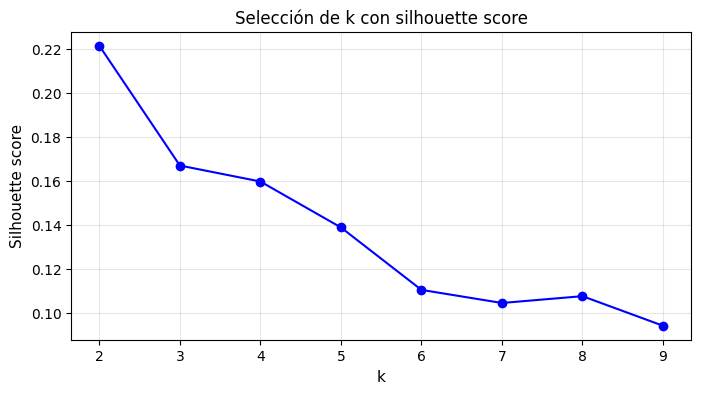

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(candidate_ks), inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(candidate_ks), silhouette_scores, 'go-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Encontrando el número óptimo de grupos

El número de grupos o *clusters* es un hiperparámetro del modelo que debemos definir. Como en este caso no tenemos etiquetas reales, probamos distintos valores de $k$ y utilizamos métricas como *silhouette score* y la inercia (*inertia*) para justificar la elección.


In [ ]:
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=256, n_init=10)
cluster_ids = kmeans.fit_predict(X_reduced)

unique_clusters, cluster_counts = np.unique(cluster_ids, return_counts=True)
print('Distribución de clusters:')
for cluster_id, count in zip(unique_clusters, cluster_counts):
    print(f' - Cluster {cluster_id}: {count} imágenes')


Distribución de clusters:
 - Cluster 0: 3735 imágenes
 - Cluster 1: 6267 imágenes


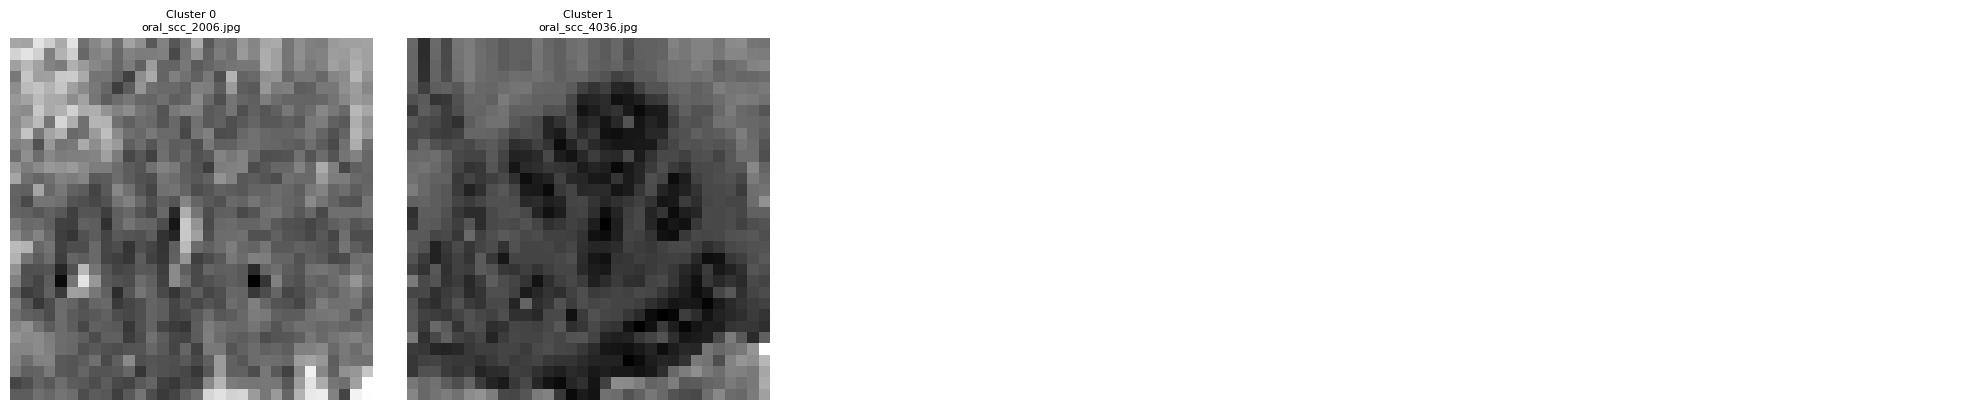

In [9]:
def show_representative_images(images, X_reduced, cluster_ids, centroids, image_paths, n_cols=5):
    representatives = []
    for cluster_id in range(len(centroids)):
        members = np.where(cluster_ids == cluster_id)[0]
        if len(members) == 0:
            continue
        distances = np.linalg.norm(X_reduced[members] - centroids[cluster_id], axis=1)
        representative_index = members[np.argmin(distances)]
        representatives.append(representative_index)

    n_items = len(representatives)
    n_rows = math.ceil(n_items / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx in range(len(axes)):
        axes[idx].axis('off')

    for plot_idx, image_index in enumerate(representatives):
        axes[plot_idx].imshow(images[image_index], cmap='gray')
        axes[plot_idx].set_title(f'Cluster {cluster_ids[image_index]}\n{image_paths[image_index].name}', fontsize=8)

    plt.tight_layout()
    plt.show()

show_representative_images(images, X_reduced, cluster_ids, kmeans.cluster_centers_, used_paths)

### K-Means para aprendizaje semi-supervisado

El aprendizaje semi-supervisado comprende las técnicas que nos permiten entrenar modelos con datos parcialmente interpretados. En esta práctica, primero agrupamos las imágenes con K-Means y luego asignamos manualmente una interpretación a cada grupo para poder presentar resultados en clase.


In [14]:
# Interpretación manual sugerida de los 4 clusters.
# Ojo: estos nombres no salen automáticamente del algoritmo; se asignan después de revisar las imágenes representativas.
cluster_to_label = {
    0: 'normal',
    1: 'cancer frente',
    2: 'cancer lado izquierdo',
    3: 'cancer lado derecho'
}

if len(cluster_to_label) == 4:
    pseudo_labels = np.array([cluster_to_label[c] for c in cluster_ids])
    print('Interpretación de clusters lista para presentación.')
    for cluster_id, label in cluster_to_label.items():
        print(f'Cluster {cluster_id}: {label}')
else:
    print('Todavia no hay etiquetas suficientes para pasar a la parte semi-supervisada.')


Interpretación de clusters lista para presentación.
Cluster 0: normal
Cluster 1: cancer frente
Cluster 2: cancer lado izquierdo
Cluster 3: cancer lado derecho
